In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import os
import time
import copy

# Tekrarlanabilirlik (Seed)
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# GPU Kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")
if torch.cuda.is_available():
    print(f"GPU Modeli: {torch.cuda.get_device_name(0)}")

Kullanılan Cihaz: cuda
GPU Modeli: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
data_dir = "panel_data" 

BATCH_SIZE = 96 # Hafif modeller olduğu için batch size yüksek tutulabilir
NUM_WORKERS = 0 # Windows için 0

# Veri Dönüşümleri (Augmentation)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

try:
    full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
    class_names = full_dataset.classes
    print(f"Sınıflar: {class_names}")

    # Split
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

    val_dataset.dataset.transform = data_transforms['val']
    test_dataset.dataset.transform = data_transforms['val']

    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    }
    dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
    print(f"Veri Sayıları -> Train: {dataset_sizes['train']}, Val: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

except Exception as e:
    print("HATA:", e)

Sınıflar: ['Kirli', 'Temiz']
Veri Sayıları -> Train: 2542, Val: 544, Test: 546


In [3]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    model.load_state_dict(best_model_wts)
    return model, history

def visualize_history(history, title="Model"):
    acc = history['train_acc']
    val_acc = history['val_acc']
    epochs_range = range(len(acc))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

def evaluate_model_full(model, title="Model"):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs[:, 1].cpu().numpy())
            
    print(f"\n--- {title} DETAYLI RAPOR ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') 
    plt.title(f'{title} Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{title} ROC Curve')
    plt.legend()
    plt.show()

# ÖZEL FONKSİYON: Verimlilik Ölçümü
def measure_efficiency(model, device, model_name="Model"):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    
    # 1. Parametre Sayısı
    param_size = sum(p.numel() for p in model.parameters())
    print(f"{model_name} Parametre Sayısı: {param_size / 1_000_000:.2f} Milyon")
    
    # 2. Hız Testi
    with torch.no_grad():
        for _ in range(20): _ = model(dummy_input) # Isınma
        
    start = time.time()
    with torch.no_grad():
        for _ in range(200): _ = model(dummy_input) # 200 tahmin
    end = time.time()
    
    avg_time = (end - start) / 200
    fps = 1.0 / avg_time
    print(f"{model_name} Ortalama Süre: {avg_time*1000:.2f} ms")
    print(f"{model_name} FPS (Kare/Saniye): {fps:.1f}")

=== MODEL 1: EfficientNet B0 Eğitiliyor ===


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Rabotyaga/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:16<00:00, 1.33MB/s]


Epoch 1/15
----------


c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train Loss: 0.3971 Acc: 0.8139
val Loss: 0.3289 Acc: 0.8842

Epoch 2/15
----------
train Loss: 0.1787 Acc: 0.9359
val Loss: 0.3636 Acc: 0.8934

Epoch 3/15
----------
train Loss: 0.0891 Acc: 0.9658
val Loss: 0.3250 Acc: 0.8897

Epoch 4/15
----------
train Loss: 0.0618 Acc: 0.9780
val Loss: 0.4477 Acc: 0.8915

Epoch 5/15
----------
train Loss: 0.0807 Acc: 0.9736
val Loss: 0.4968 Acc: 0.9026

Epoch 6/15
----------
train Loss: 0.0680 Acc: 0.9795
val Loss: 0.4894 Acc: 0.8842

Epoch 7/15
----------
train Loss: 0.0742 Acc: 0.9756
val Loss: 0.4345 Acc: 0.9007

Epoch 8/15
----------
train Loss: 0.0349 Acc: 0.9902
val Loss: 0.4136 Acc: 0.9044

Epoch 9/15
----------
train Loss: 0.0265 Acc: 0.9910
val Loss: 0.4163 Acc: 0.9026

Epoch 10/15
----------
train Loss: 0.0186 Acc: 0.9917
val Loss: 0.4151 Acc: 0.9044

Epoch 11/15
----------
train Loss: 0.0167 Acc: 0.9941
val Loss: 0.4245 Acc: 0.9007

Epoch 12/15
----------
train Loss: 0.0161 Acc: 0.9941
val Loss: 0.4194 Acc: 0.9026

Epoch 13/15
----------


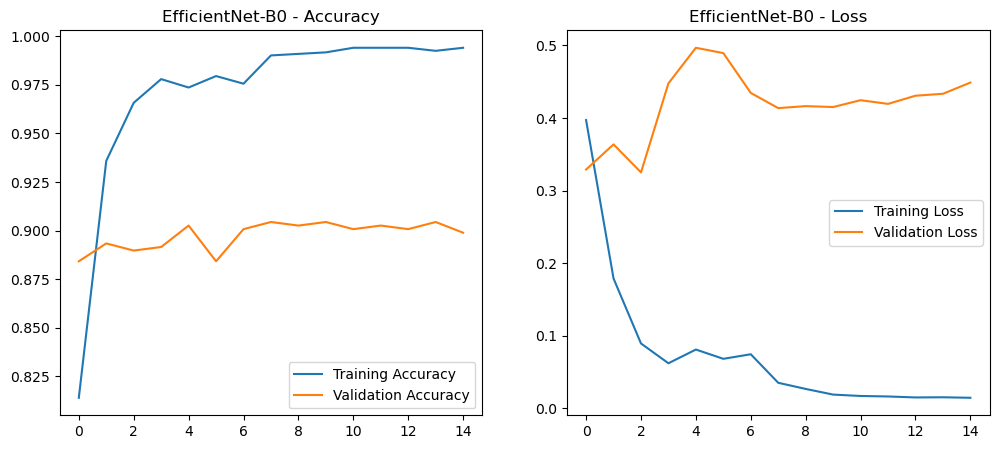


--- EfficientNet-B0 DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.88      0.91      0.89       255
       Temiz       0.92      0.89      0.90       291

    accuracy                           0.90       546
   macro avg       0.90      0.90      0.90       546
weighted avg       0.90      0.90      0.90       546



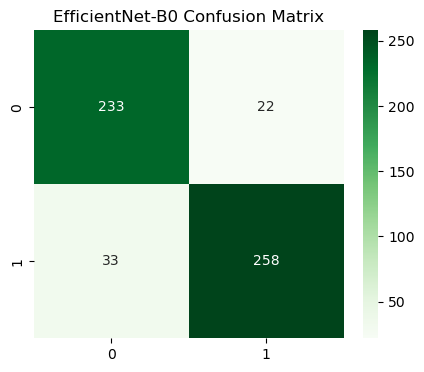

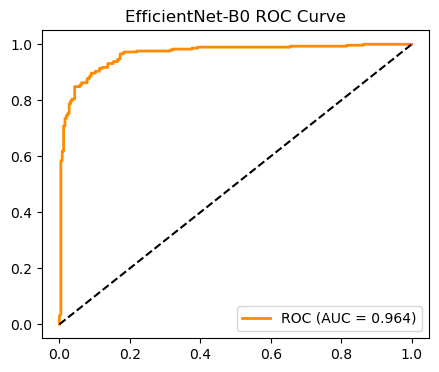

EfficientNet-B0 Parametre Sayısı: 4.01 Milyon
EfficientNet-B0 Ortalama Süre: 17.36 ms
EfficientNet-B0 FPS (Kare/Saniye): 57.6


In [4]:
print("=== MODEL 1: EfficientNet B0 Eğitiliyor ===")

# 1. Modeli Yükle
model_eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Classifier Kısmını 
# EfficientNet'in son katmanı 'classifier' içinde Sequential bir yapıdır.
# Genelde classifier[1] Linear katmandır.
num_ftrs = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Linear(num_ftrs, 2)

model_eff = model_eff.to(device)

# 3. Ayarlar
criterion = nn.CrossEntropyLoss()
optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.001)
exp_lr_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer_eff, mode='min', factor=0.1, patience=3)

# 4. Eğitim
model_eff, history_eff = train_model(
    model_eff, criterion, optimizer_eff, exp_lr_scheduler, num_epochs=15
)

# 5. Değerlendirme
visualize_history(history_eff, title="EfficientNet-B0")
evaluate_model_full(model_eff, title="EfficientNet-B0")
measure_efficiency(model_eff, device, "EfficientNet-B0")

torch.save(model_eff.state_dict(), 'PATtechs_EfficientNetB0_Final.pth')

=== MODEL 2: MobileNet v3 Large Eğitiliyor ===


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\Rabotyaga/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:16<00:00, 1.32MB/s]


Epoch 1/15
----------


c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train Loss: 0.3955 Acc: 0.8179
val Loss: 0.7146 Acc: 0.7702

Epoch 2/15
----------
train Loss: 0.1666 Acc: 0.9418
val Loss: 0.6366 Acc: 0.8070

Epoch 3/15
----------
train Loss: 0.0832 Acc: 0.9701
val Loss: 0.4772 Acc: 0.8548

Epoch 4/15
----------
train Loss: 0.0686 Acc: 0.9748
val Loss: 0.5020 Acc: 0.8879

Epoch 5/15
----------
train Loss: 0.0400 Acc: 0.9858
val Loss: 0.4646 Acc: 0.8915

Epoch 6/15
----------
train Loss: 0.0540 Acc: 0.9780
val Loss: 0.7602 Acc: 0.8529

Epoch 7/15
----------
train Loss: 0.0810 Acc: 0.9705
val Loss: 0.6646 Acc: 0.8658

Epoch 8/15
----------
train Loss: 0.0588 Acc: 0.9776
val Loss: 0.5986 Acc: 0.8585

Epoch 9/15
----------
train Loss: 0.0571 Acc: 0.9795
val Loss: 0.5240 Acc: 0.8915

Epoch 10/15
----------
train Loss: 0.0244 Acc: 0.9910
val Loss: 0.4965 Acc: 0.9044

Epoch 11/15
----------
train Loss: 0.0126 Acc: 0.9953
val Loss: 0.5103 Acc: 0.9081

Epoch 12/15
----------
train Loss: 0.0111 Acc: 0.9957
val Loss: 0.4960 Acc: 0.9099

Epoch 13/15
----------


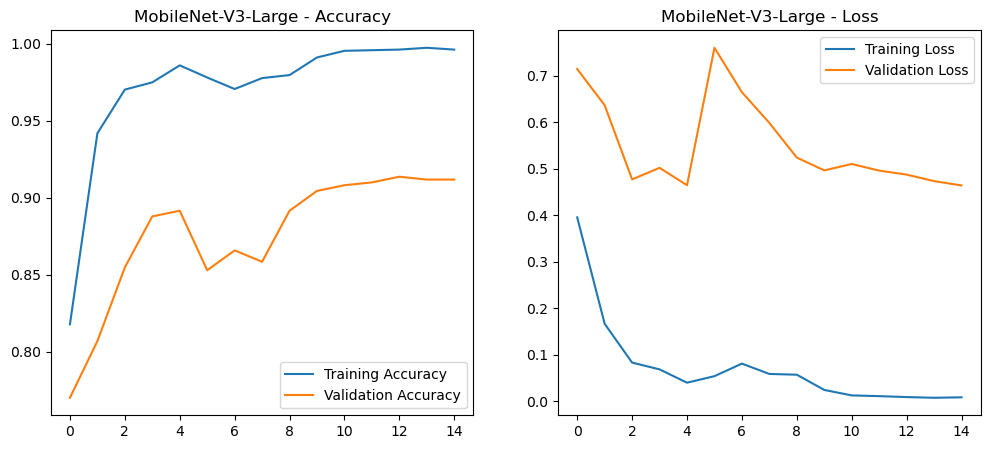


--- MobileNet-V3-Large DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.88      0.90      0.89       255
       Temiz       0.91      0.90      0.90       291

    accuracy                           0.90       546
   macro avg       0.90      0.90      0.90       546
weighted avg       0.90      0.90      0.90       546



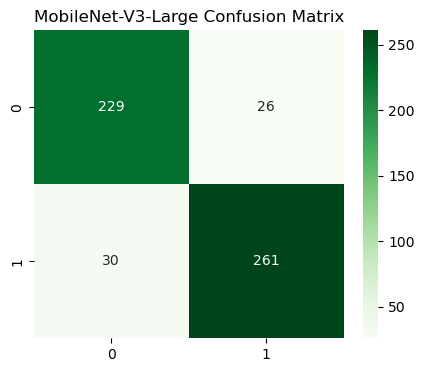

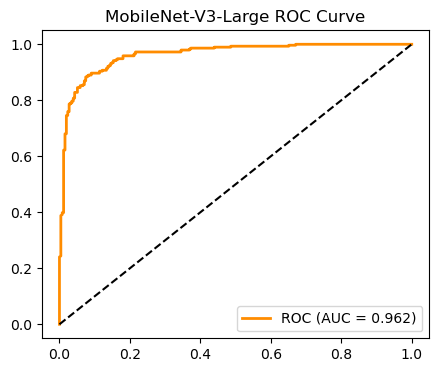

MobileNet-V3-Large Parametre Sayısı: 4.20 Milyon
MobileNet-V3-Large Ortalama Süre: 3.71 ms
MobileNet-V3-Large FPS (Kare/Saniye): 269.6


In [5]:
print("=== MODEL 2: MobileNet v3 Large Eğitiliyor ===")

# 1. Modeli Yükle
model_mob = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

# 2. Classifier Kısmını Değiştir
# MobileNetV3'te son katman classifier[3]'tür
num_ftrs = model_mob.classifier[3].in_features
model_mob.classifier[3] = nn.Linear(num_ftrs, 2)

model_mob = model_mob.to(device)

# 3. Ayarlar
criterion = nn.CrossEntropyLoss()
optimizer_mob = optim.Adam(model_mob.parameters(), lr=0.001)
exp_lr_scheduler_mob = lr_scheduler.ReduceLROnPlateau(optimizer_mob, mode='min', factor=0.1, patience=3)

# 4. Eğitim
model_mob, history_mob = train_model(
    model_mob, criterion, optimizer_mob, exp_lr_scheduler_mob, num_epochs=15
)

# 5. Değerlendirme
visualize_history(history_mob, title="MobileNet-V3-Large")
evaluate_model_full(model_mob, title="MobileNet-V3-Large")
measure_efficiency(model_mob, device, "MobileNet-V3-Large")

torch.save(model_mob.state_dict(), 'PATtechs_MobileNetV3_Final.pth')

Verimlilik Odaklı Modeller İçin Heatmap:


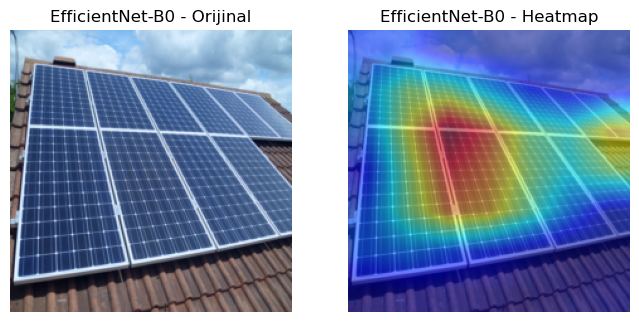

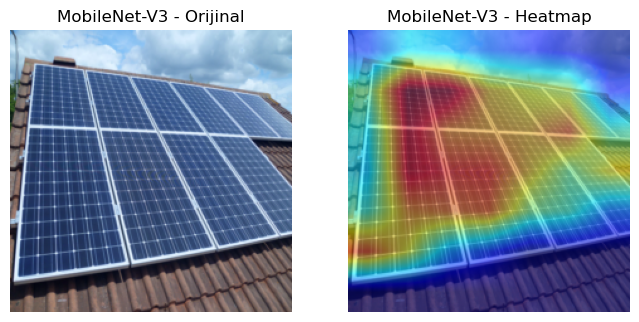

In [6]:
# Grad-CAM 
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import sys
    !{sys.executable} -m pip install grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def show_gradcam(model, target_layer, dataset, title="Grad-CAM"):
    model.eval()
    idx = 0
    while True:
        img, label = dataset[idx]
        if label == 1: break # Kirli resim bul
        idx += 1
        
    input_tensor = img.unsqueeze(0).to(device)
    rgb_img = img.permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(1)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"{title} - Orijinal")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"{title} - Heatmap")
    plt.axis('off')
    plt.show()

print("Verimlilik Odaklı Modeller İçin Heatmap:")
# EfficientNet ve MobileNet için son özellik katmanı 'features[-1]' dir
show_gradcam(model_eff, model_eff.features[-1], test_dataset, "EfficientNet-B0")
show_gradcam(model_mob, model_mob.features[-1], test_dataset, "MobileNet-V3")